In [2]:

import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt


DATASET_PATH = "/kaggle/input/food-vs-fruit-dataset/Project Data/Fruit"


TRAIN_PATH = os.path.join(DATASET_PATH, "Train")

def natural_sort(l):
    import re
    return sorted(l, key=lambda x: [int(t) if t.isdigit() else t.lower() for t in re.split('(\d+)', x)])
    

class FruitBinarySegmentationDataset(Dataset):
    def __init__(self, root_dir, img_size=256):
        self.img_size = img_size
        self.images = []
        self.masks = []

        fruit_classes = os.listdir(root_dir)
        for fruit in fruit_classes:
            fruit_path = os.path.join(root_dir, fruit)

            img_dir = os.path.join(fruit_path, "Images")
            mask_dir = os.path.join(fruit_path, "Mask")

            if not os.path.isdir(img_dir) or not os.path.isdir(mask_dir):
                continue

            img_files = natural_sort([f for f in os.listdir(img_dir) if f.endswith(('.jpg','.png','.jpeg'))])
            mask_files = natural_sort([f for f in os.listdir(mask_dir) if f.endswith(('.jpg','.png','.jpeg'))])

            for img_name, mask_name in zip(img_files, mask_files):
                self.images.append(os.path.join(img_dir, img_name))
                self.masks.append(os.path.join(mask_dir, mask_name))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # read images
        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_size, self.img_size))
        image = image.astype('float32') / 255.0

        #read mask
        mask = cv2.imread(self.masks[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size))
        mask = (mask > 127).astype('float32')

        # tensors
        image = torch.tensor(image).permute(2,0,1)
        mask = torch.tensor(mask).unsqueeze(0)

        return image, mask


Total images found: 1759
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])


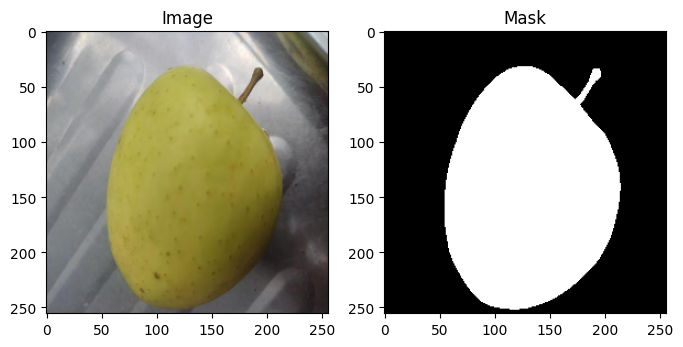

In [3]:
dataset = FruitBinarySegmentationDataset(TRAIN_PATH)
print("Total images found:", len(dataset))

img, mask = dataset[0]
print("Image shape:", img.shape)
print("Mask shape:", mask.shape)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))
plt.title("Image")
plt.subplot(1,2,2)
plt.imshow(mask[0], cmap='gray')
plt.title("Mask")
plt.show()


In [4]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

# read one beach
for imgs, masks in train_loader:
    print("Batch images shape:", imgs.shape)
    print("Batch masks shape:", masks.shape)
    break


Batch images shape: torch.Size([16, 3, 256, 256])
Batch masks shape: torch.Size([16, 1, 256, 256])


In [7]:
# Install segmentation_models_pytorch if not installed
!pip install segmentation-models-pytorch --quiet

In [5]:

import os
import time
import torch
import segmentation_models_pytorch as smp

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Model
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

# Loss & Optimizer
criterion = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=False)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Save path
save_dir = "/kaggle/working/"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "best_train_unet_full_model.pth")

best_train_loss = float('inf')
num_epochs = 20
num_batches = len(train_loader)

print(f"Total batches per epoch: {num_batches}")

# ⏱️ Total training time
total_start_time = time.time()

for epoch in range(num_epochs):
    epoch_start_time = time.time()

    model.train()
    total_loss = 0
    correct_pixels = 0
    total_pixels = 0

    for imgs, masks in train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        preds = model(imgs)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # -------- Accuracy (pixel-wise) --------
        preds_bin = (preds > 0.5).float()
        correct_pixels += (preds_bin == masks).sum().item()
        total_pixels += masks.numel()

    avg_train_loss = total_loss / num_batches
    train_accuracy = correct_pixels / total_pixels

    epoch_time = time.time() - epoch_start_time
    total_elapsed = time.time() - total_start_time

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss   : {avg_train_loss:.4f}")
    print(f"Train Acc    : {train_accuracy:.4f}")
    print(f"Epoch Time   : {epoch_time:.2f} sec")
    print(f"Total Time   : {total_elapsed:.2f} sec")

    # Save best model
    if avg_train_loss < best_train_loss:
        best_train_loss = avg_train_loss
        torch.save(model, save_path)
        print(f"--> Best model saved (Loss = {best_train_loss:.4f})")

print("\nTraining finished ✅")
print(f"Best full model saved at: {save_path}")


Using device: cuda
Total batches per epoch: 110

Epoch [1/20]
Train Loss   : 0.2320
Train Acc    : 0.9302
Epoch Time   : 24.59 sec
Total Time   : 24.59 sec
--> Best model saved (Loss = 0.2320)

Epoch [2/20]
Train Loss   : 0.0813
Train Acc    : 0.9821
Epoch Time   : 22.40 sec
Total Time   : 47.12 sec
--> Best model saved (Loss = 0.0813)

Epoch [3/20]
Train Loss   : 0.0630
Train Acc    : 0.9857
Epoch Time   : 23.09 sec
Total Time   : 70.43 sec
--> Best model saved (Loss = 0.0630)

Epoch [4/20]
Train Loss   : 0.0552
Train Acc    : 0.9881
Epoch Time   : 23.36 sec
Total Time   : 93.99 sec
--> Best model saved (Loss = 0.0552)

Epoch [5/20]
Train Loss   : 0.0537
Train Acc    : 0.9890
Epoch Time   : 23.56 sec
Total Time   : 117.75 sec
--> Best model saved (Loss = 0.0537)

Epoch [6/20]
Train Loss   : 0.0426
Train Acc    : 0.9913
Epoch Time   : 24.27 sec
Total Time   : 142.23 sec
--> Best model saved (Loss = 0.0426)

Epoch [7/20]
Train Loss   : 0.0384
Train Acc    : 0.9921
Epoch Time   : 24.97 s

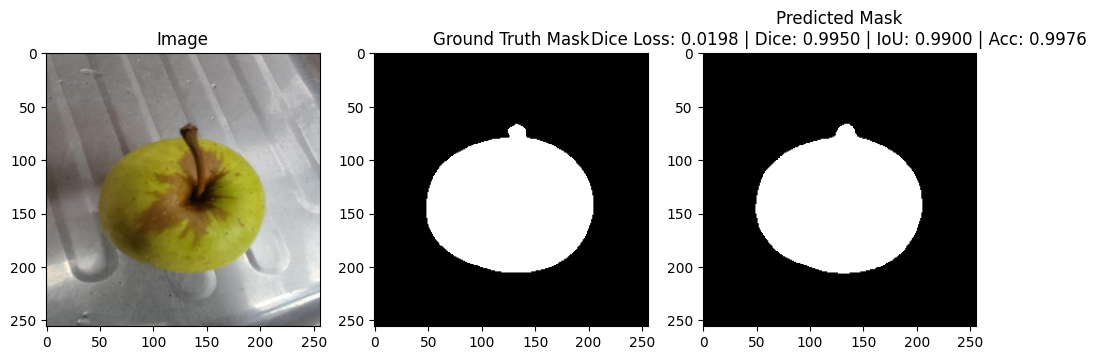

Batch 1/38 processed in 0.43 sec


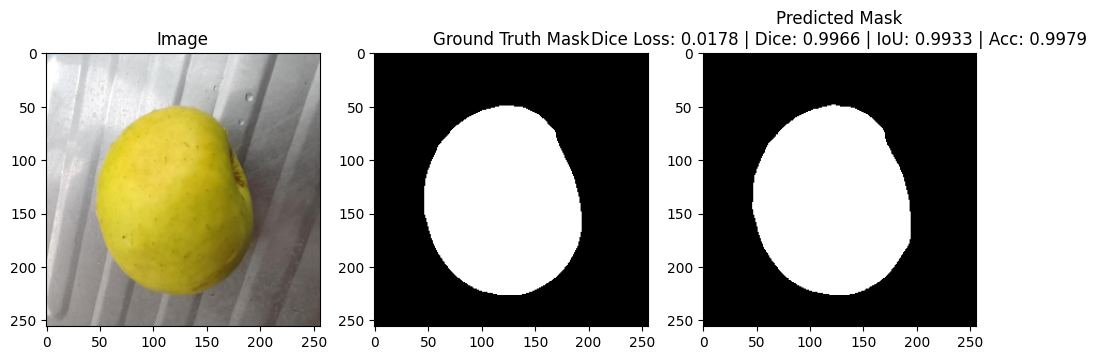

Batch 2/38 processed in 0.42 sec


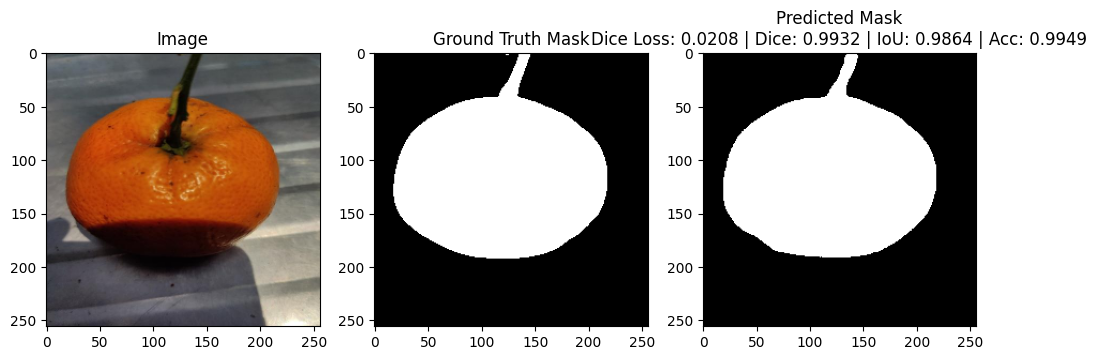

Batch 3/38 processed in 0.44 sec


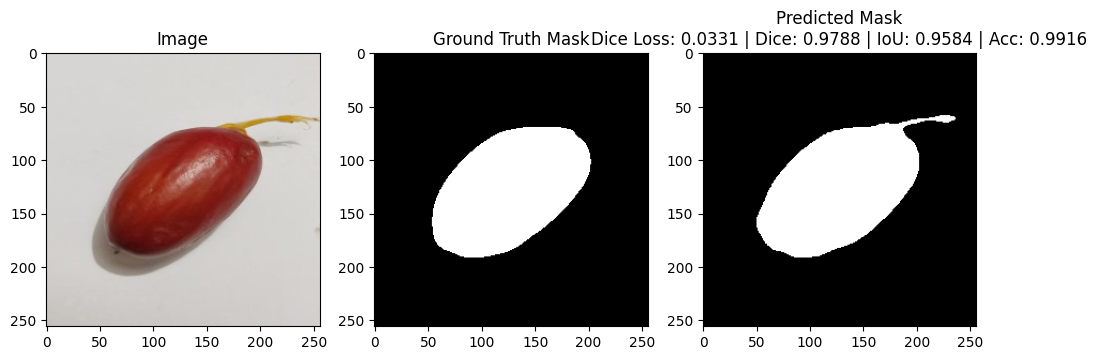

Batch 4/38 processed in 0.45 sec


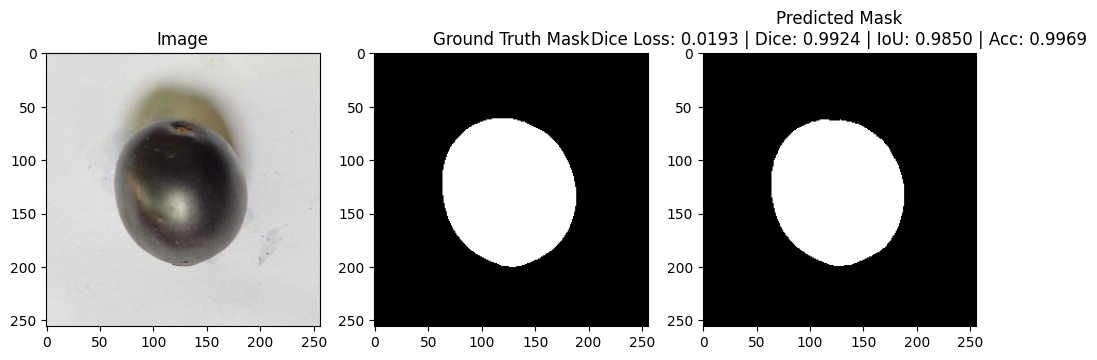

Batch 5/38 processed in 0.67 sec


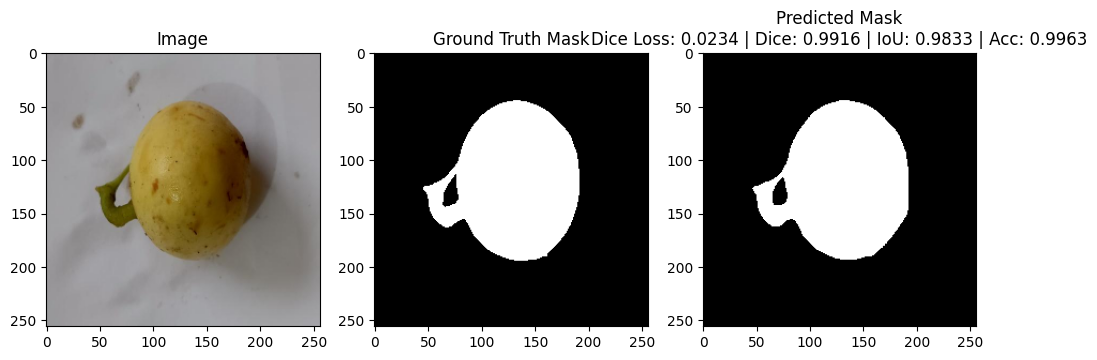

Batch 6/38 processed in 0.43 sec


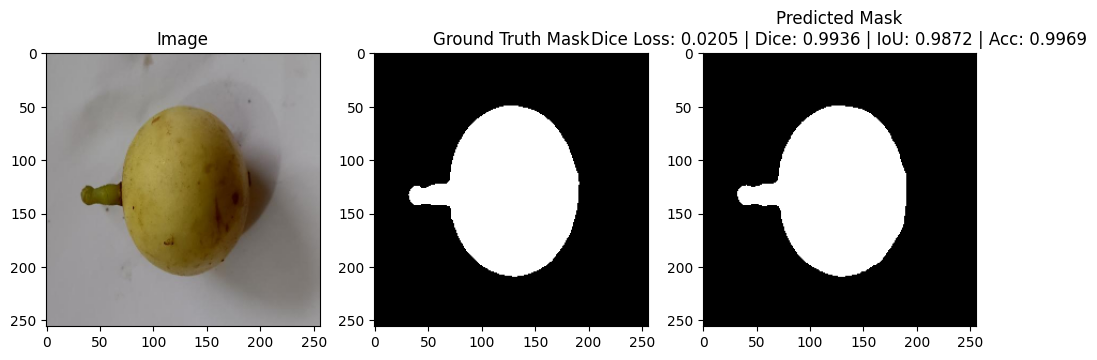

Batch 7/38 processed in 0.42 sec


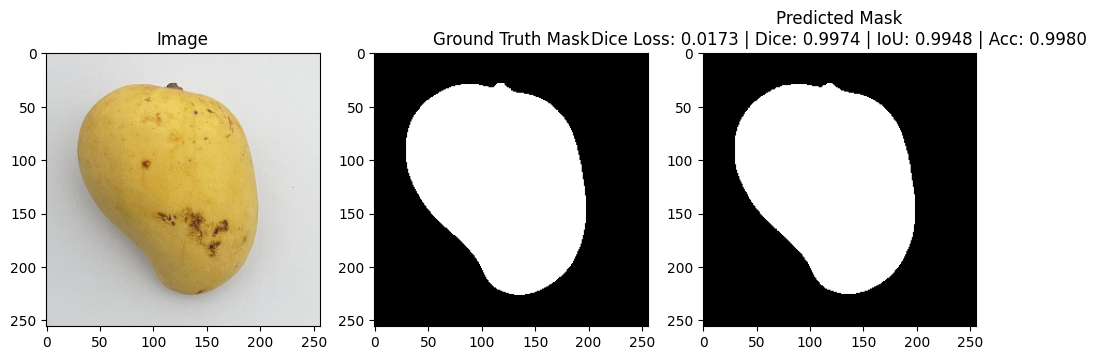

Batch 8/38 processed in 0.43 sec


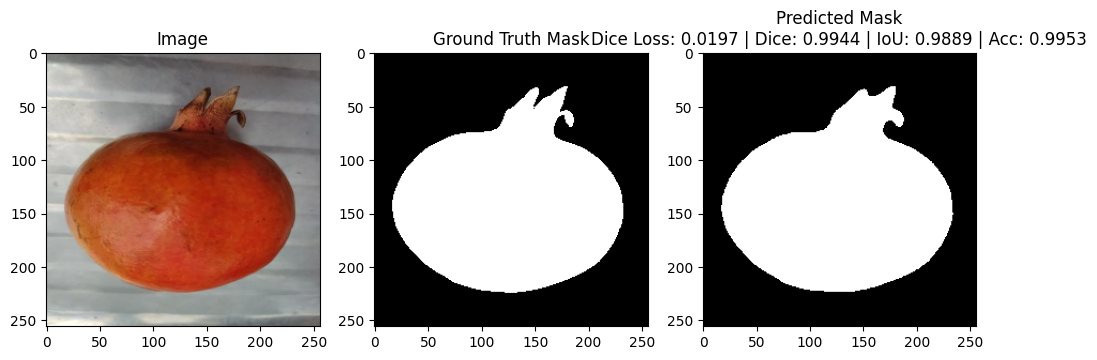

Batch 9/38 processed in 0.46 sec


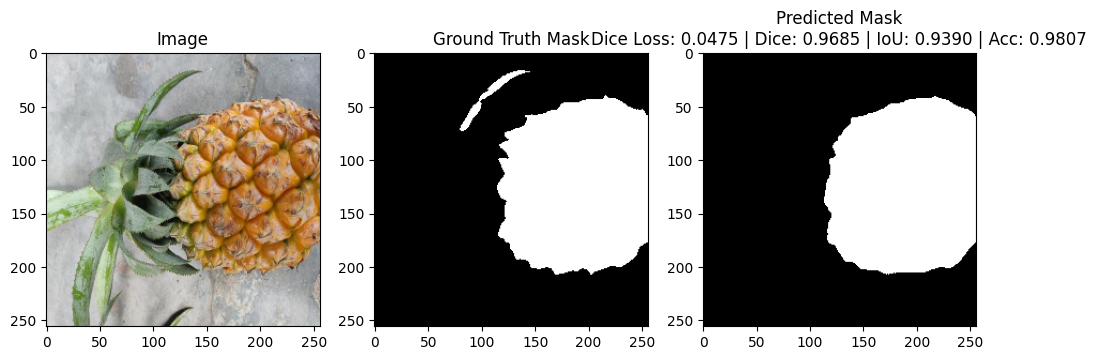

Batch 10/38 processed in 0.44 sec


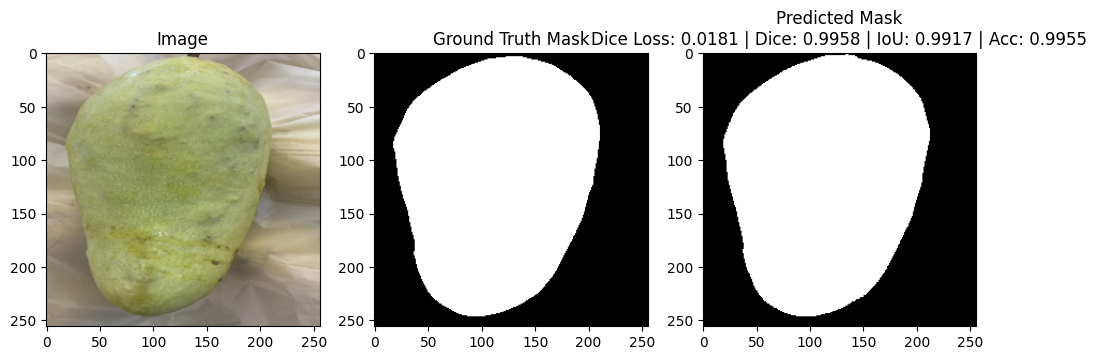

Batch 11/38 processed in 0.44 sec


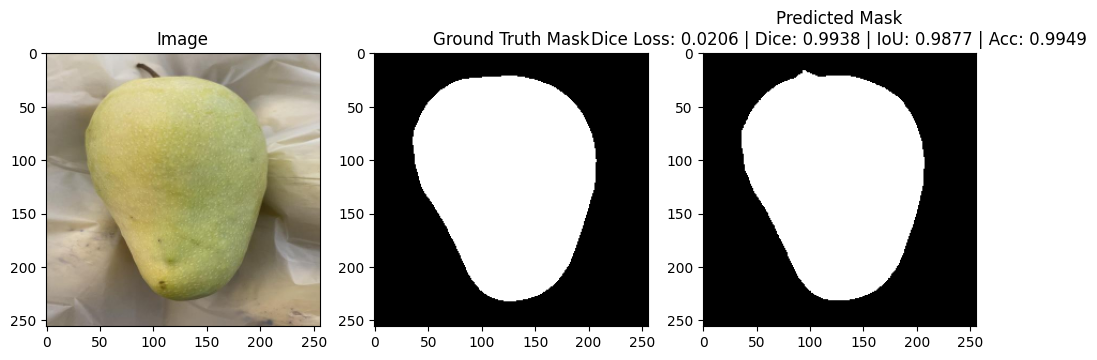

Batch 12/38 processed in 0.46 sec


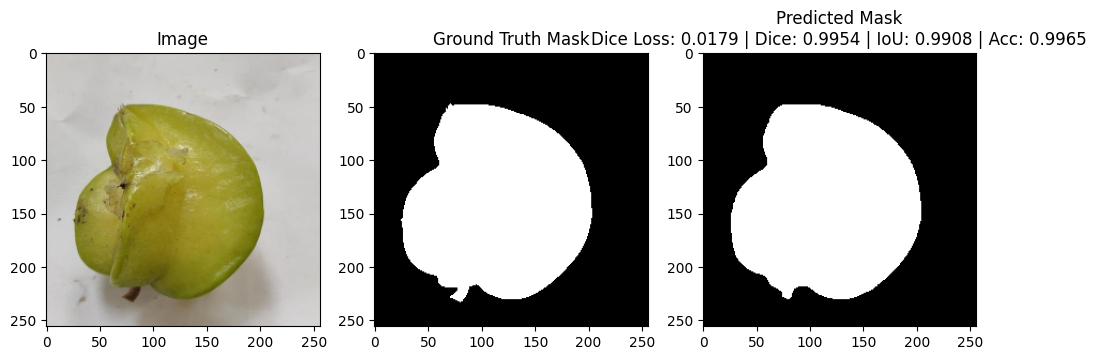

Batch 13/38 processed in 0.44 sec


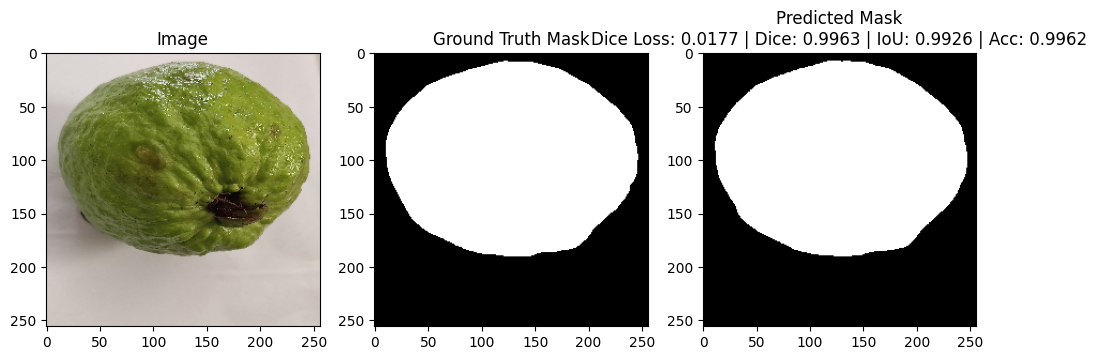

Batch 14/38 processed in 0.44 sec


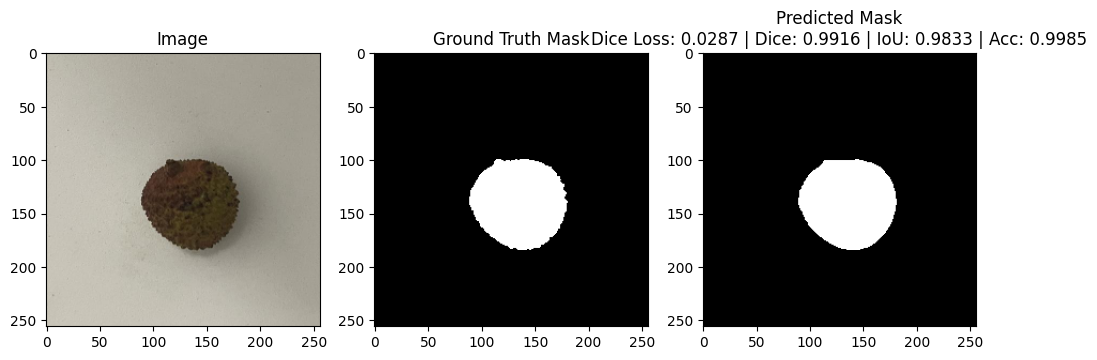

Batch 15/38 processed in 0.44 sec


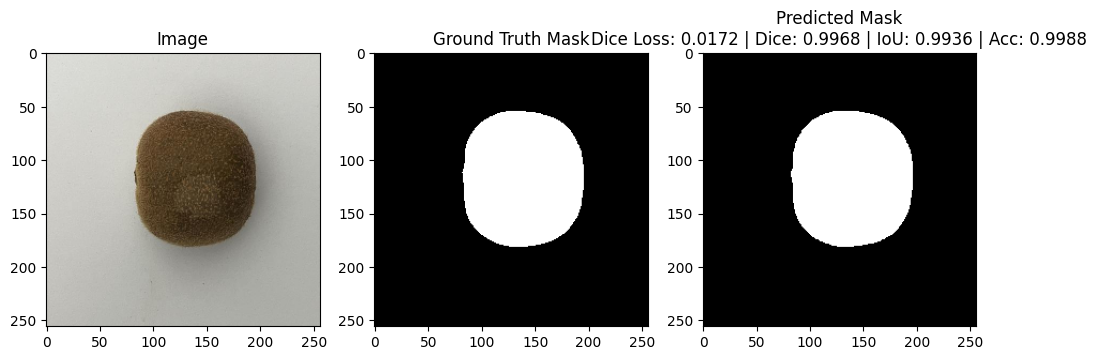

Batch 16/38 processed in 0.43 sec


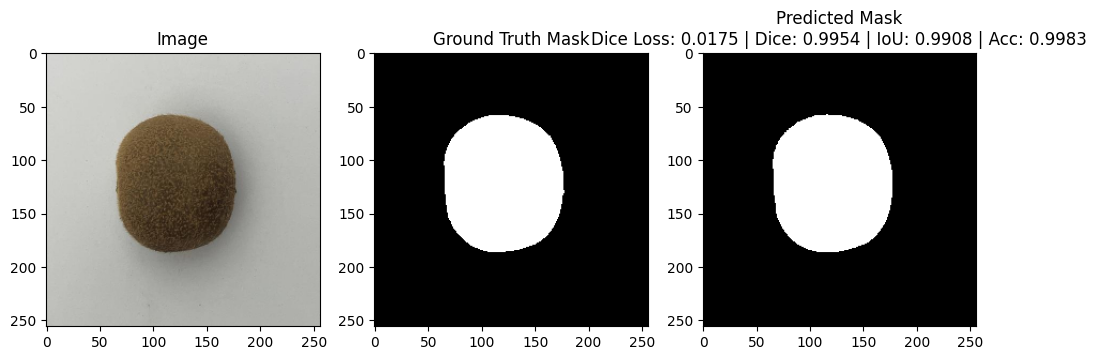

Batch 17/38 processed in 0.45 sec


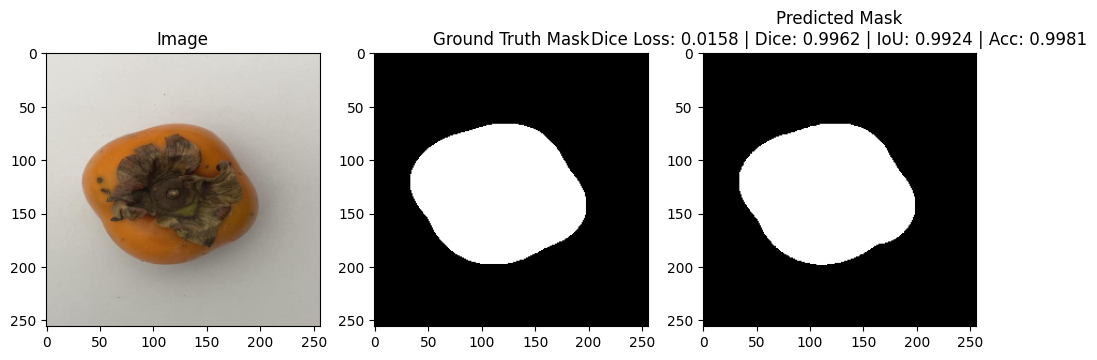

Batch 18/38 processed in 0.68 sec


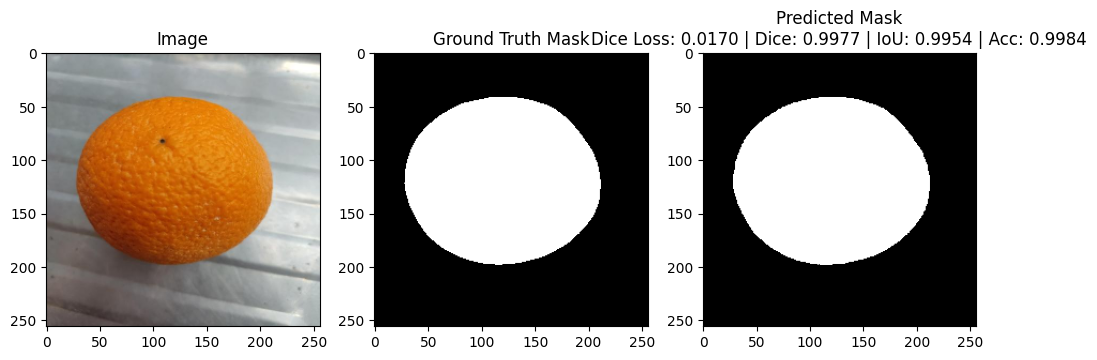

Batch 19/38 processed in 0.44 sec


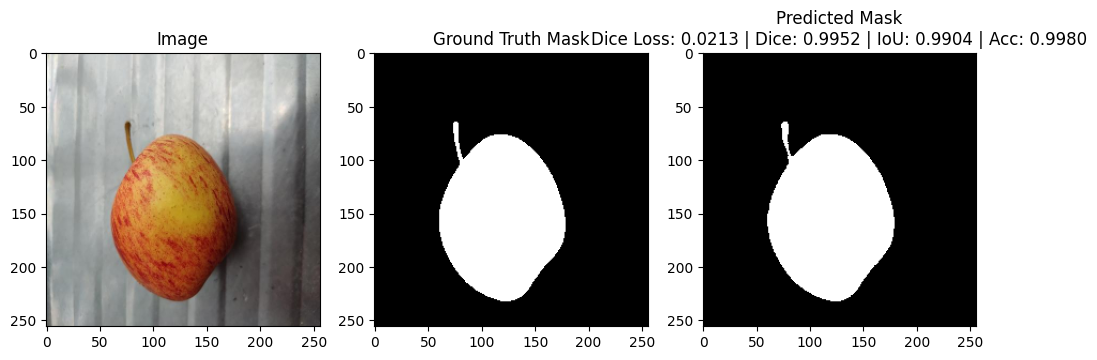

Batch 20/38 processed in 0.43 sec


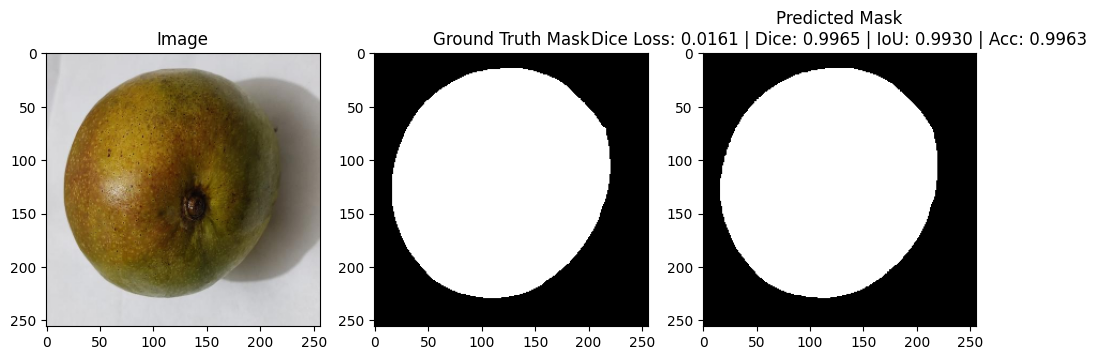

Batch 21/38 processed in 0.44 sec


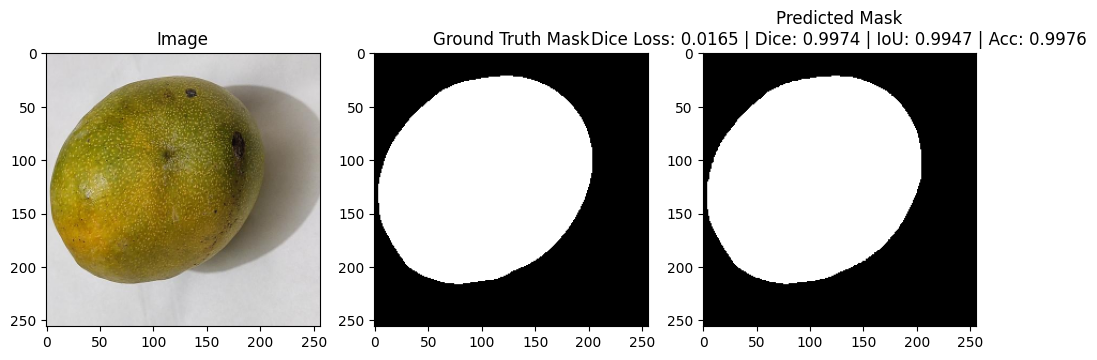

Batch 22/38 processed in 0.43 sec


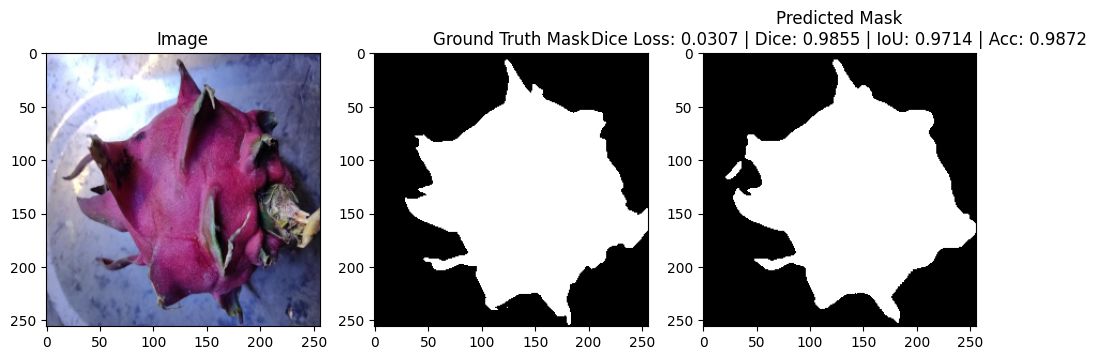

Batch 23/38 processed in 0.44 sec


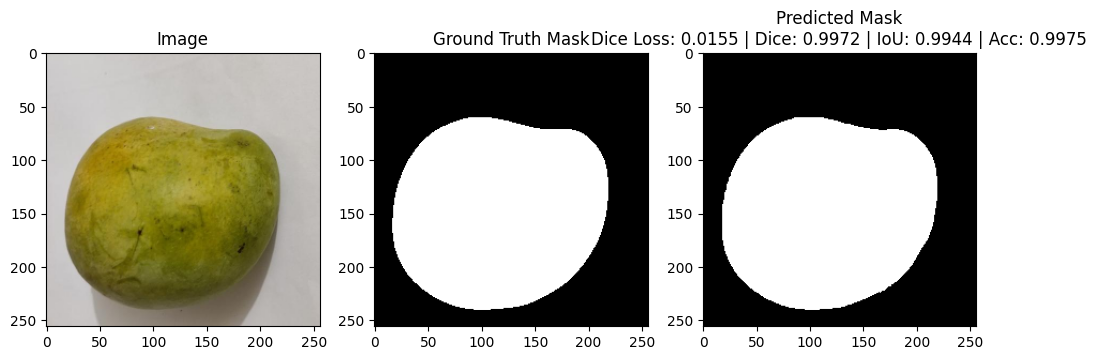

Batch 24/38 processed in 0.43 sec


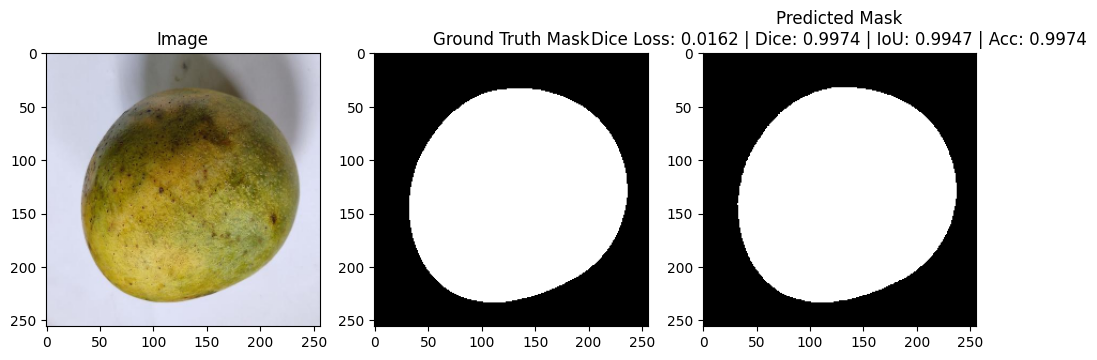

Batch 25/38 processed in 0.43 sec


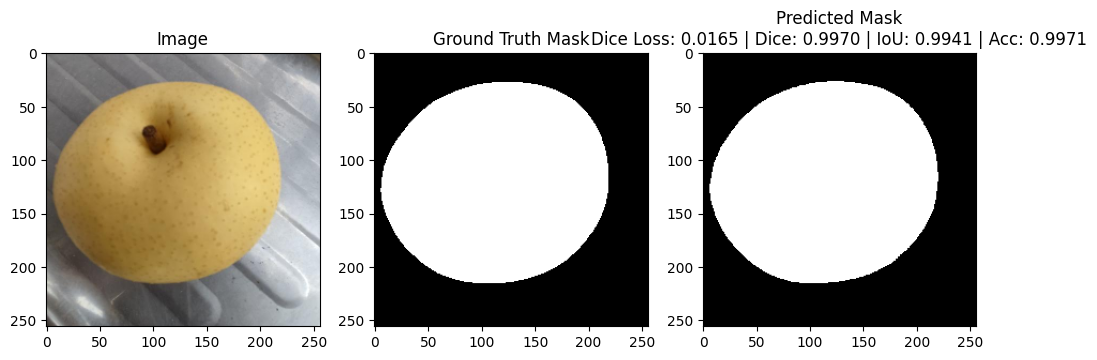

Batch 26/38 processed in 0.43 sec


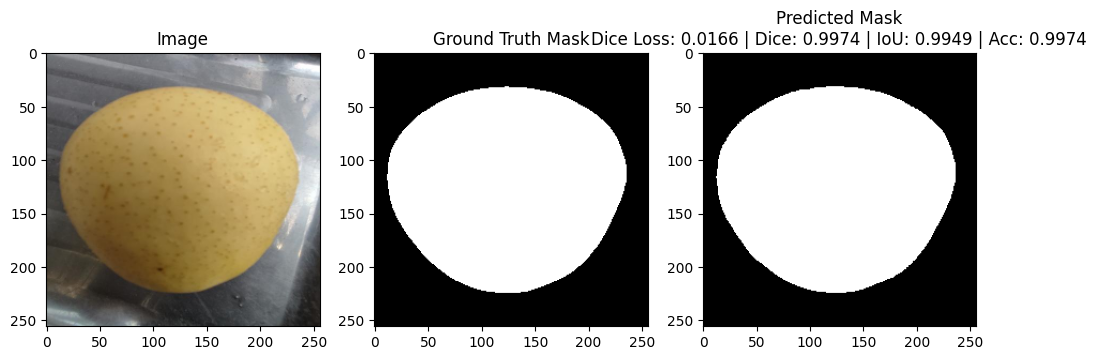

Batch 27/38 processed in 0.44 sec


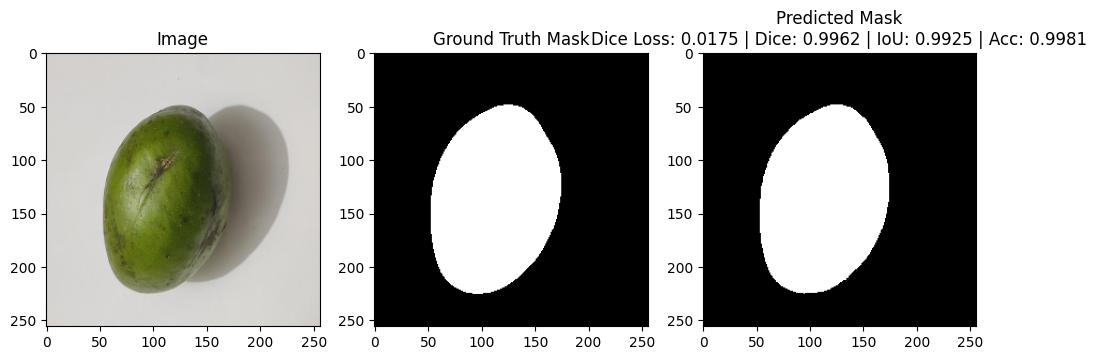

Batch 28/38 processed in 0.42 sec


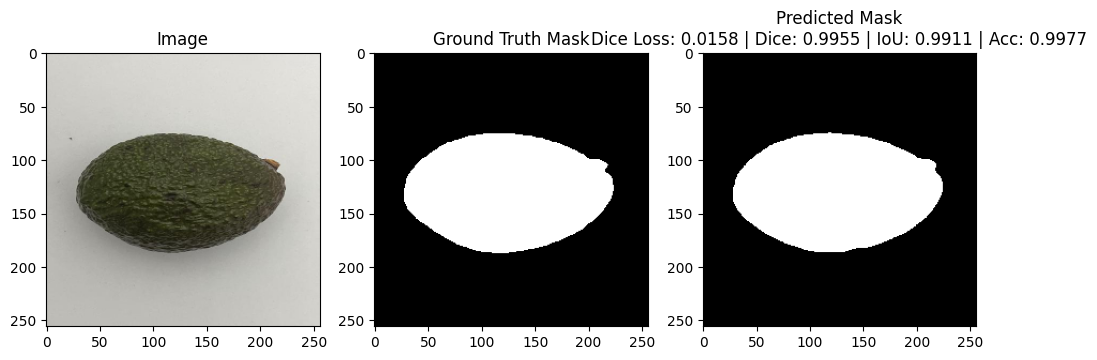

Batch 29/38 processed in 0.44 sec


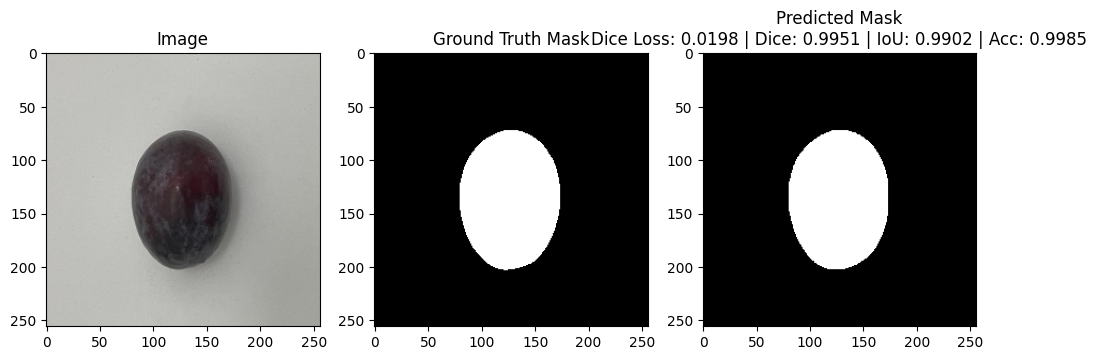

Batch 30/38 processed in 0.42 sec


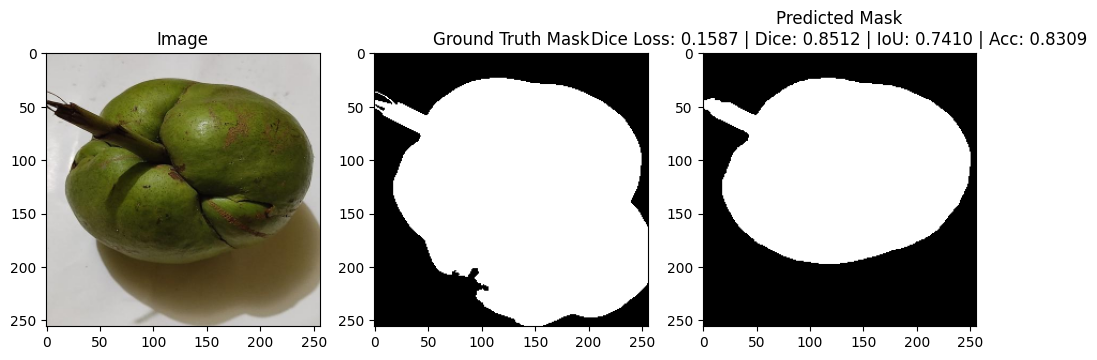

Batch 31/38 processed in 0.44 sec


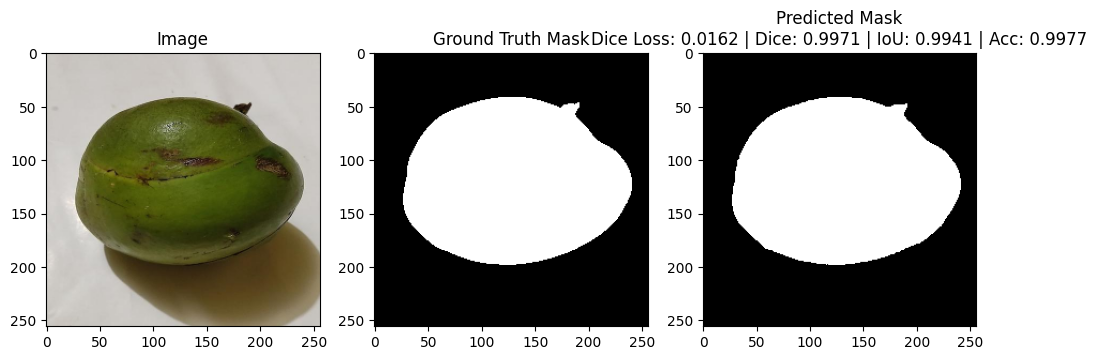

Batch 32/38 processed in 0.70 sec


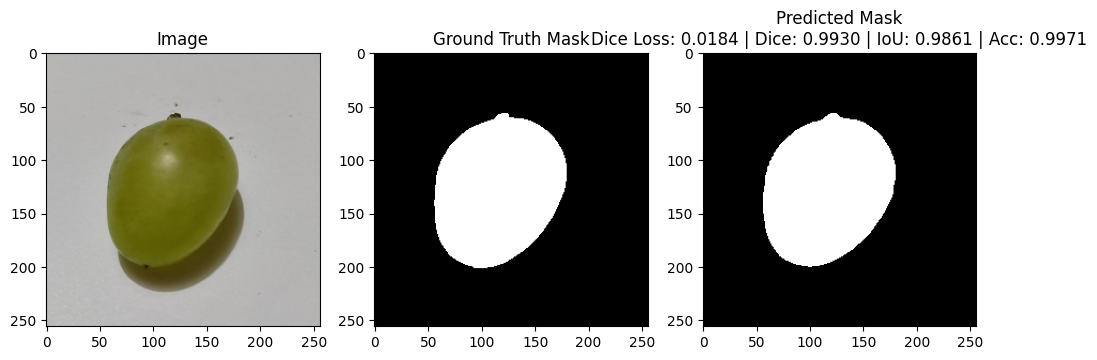

Batch 33/38 processed in 0.43 sec


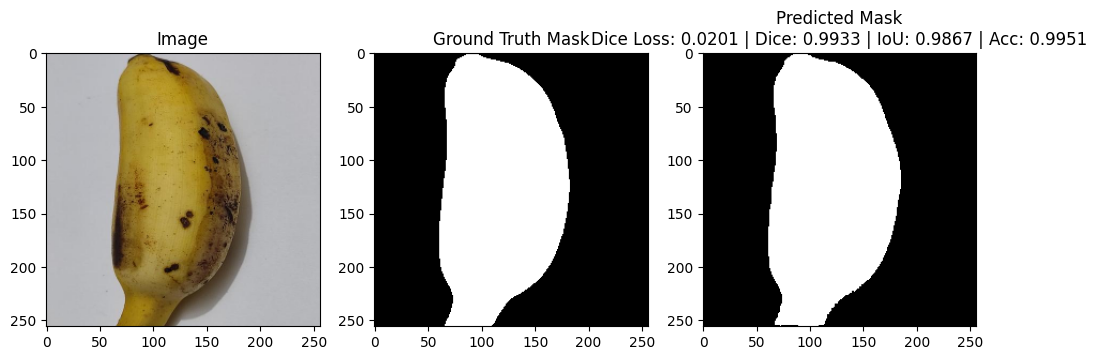

Batch 34/38 processed in 0.43 sec


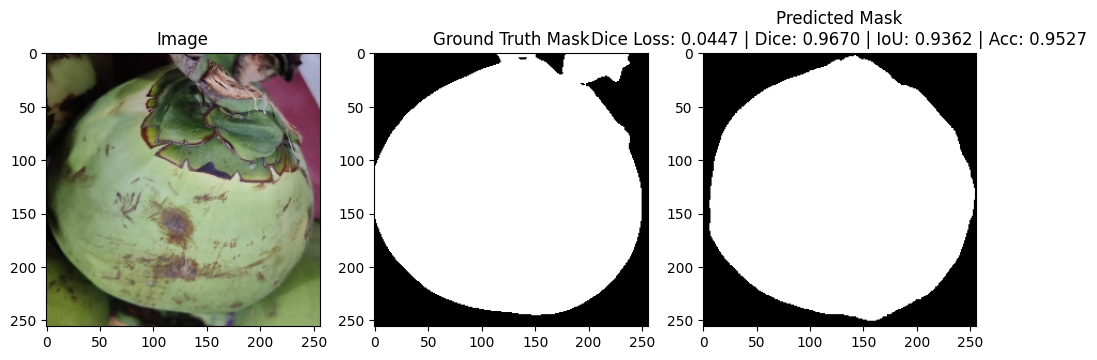

Batch 35/38 processed in 0.45 sec


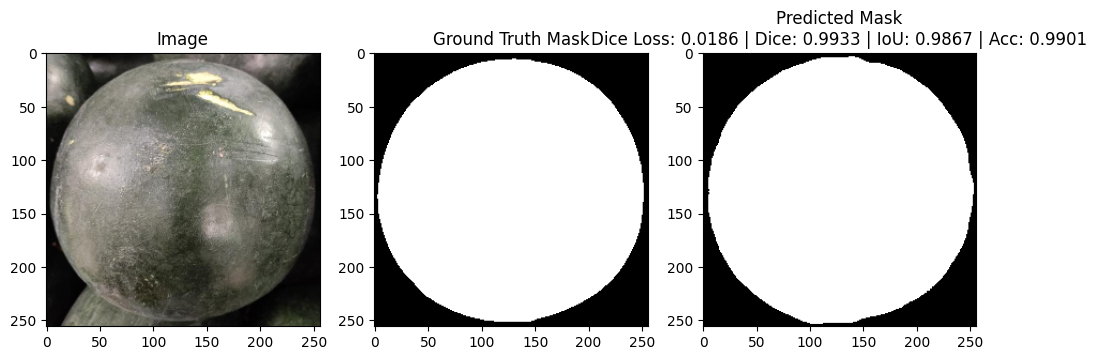

Batch 36/38 processed in 0.44 sec


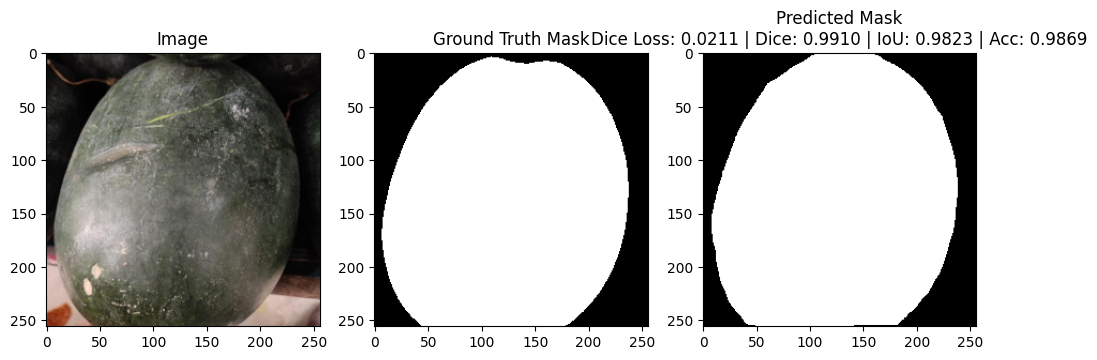

Batch 37/38 processed in 0.46 sec


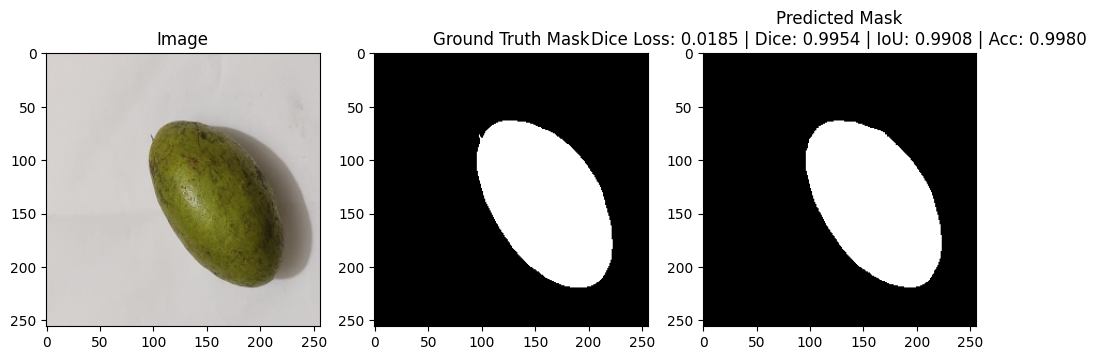

Batch 38/38 processed in 0.43 sec
===== Averages on all Validation Images =====
Average Dice Loss : 0.0273
Average Dice Score: 0.9866
Average IoU       : 0.9748
Average Accuracy  : 0.9902
Total batches: 38
Total time: 19.39 sec


In [7]:
import time
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp
import os
import cv2
from torch.utils.data import Dataset

# Dataset class
class FruitBinarySegmentationDataset(Dataset):
    def __init__(self, root_dir, img_size=256):
        self.img_size = img_size
        self.images, self.masks = [], []
        fruit_classes = os.listdir(root_dir)
        for fruit in fruit_classes:
            fruit_path = os.path.join(root_dir, fruit)
            img_dir = os.path.join(fruit_path, "Images")
            mask_dir = os.path.join(fruit_path, "Mask")
            if not os.path.isdir(img_dir) or not os.path.isdir(mask_dir):
                continue
            img_files = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg','.png','.jpeg'))])
            mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith(('.jpg','.png','.jpeg'))])
            for img_name, mask_name in zip(img_files, mask_files):
                self.images.append(os.path.join(img_dir, img_name))
                self.masks.append(os.path.join(mask_dir, mask_name))
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_size, self.img_size))
        image = image.astype('float32') / 255.0
        mask = cv2.imread(self.masks[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size))
        mask = (mask > 127).astype('float32')
        image = torch.tensor(image).permute(2,0,1)
        mask = torch.tensor(mask).unsqueeze(0)
        return image, mask

# Device and test loader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TEST_PATH = "/kaggle/input/food-vs-fruit-dataset/Project Data/Fruit/Validation"
test_dataset = FruitBinarySegmentationDataset(TEST_PATH)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False) 

# Load full model safely
model_path = "/kaggle/working/best_train_unet_full_model.pth"
with torch.serialization.safe_globals([smp.Unet]):
    model = torch.load(model_path, weights_only=False)
model.to(device)
model.eval()

# Loss function
criterion = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=False)

# Initialize metrics
total_loss = 0
total_dice = 0
total_iou = 0
total_acc = 0
total_batches = len(test_loader)

start_time = time.time()

with torch.no_grad():
    for batch_idx, (imgs, masks) in enumerate(test_loader):
        batch_start = time.time()
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        preds_bin = (preds > 0.5).float()

        # Metrics
        for i in range(imgs.size(0)):
            loss_val = criterion(preds[i:i+1], masks[i:i+1]).item()
            dice_val = ((2 * (preds_bin[i:i+1] * masks[i:i+1]).sum() + 1e-7) / 
                        (preds_bin[i:i+1].sum() + masks[i:i+1].sum() + 1e-7)).item()
            iou_val = (((preds_bin[i:i+1] * masks[i:i+1]).sum() + 1e-7) / 
                       (preds_bin[i:i+1].sum() + masks[i:i+1].sum() - (preds_bin[i:i+1] * masks[i:i+1]).sum() + 1e-7)).item()
            acc_val = (preds_bin[i:i+1].eq(masks[i:i+1]).sum().float() / masks[i:i+1].numel()).item()

            total_loss += loss_val
            total_dice += dice_val
            total_iou += iou_val
            total_acc += acc_val

            # Display first image of batch
            if i == 0:
                img_np = imgs[i].permute(1,2,0).cpu().numpy()
                mask_np = masks[i,0].cpu().numpy()
                pred_np = preds_bin[i,0].cpu().numpy()
                plt.figure(figsize=(12,4))
                plt.subplot(1,3,1)
                plt.imshow(img_np)
                plt.title("Image")
                plt.subplot(1,3,2)
                plt.imshow(mask_np, cmap='gray')
                plt.title("Ground Truth Mask")
                plt.subplot(1,3,3)
                plt.imshow(pred_np, cmap='gray')
                plt.title(f"Predicted Mask\nDice Loss: {loss_val:.4f} | Dice: {dice_val:.4f} | IoU: {iou_val:.4f} | Acc: {acc_val:.4f}")
                plt.show()

        batch_end = time.time()
        print(f"Batch {batch_idx+1}/{total_batches} processed in {batch_end-batch_start:.2f} sec")

end_time = time.time()
print("===== Averages on all Validation Images =====")
num_images = len(test_dataset)
print(f"Average Dice Loss : {total_loss/num_images:.4f}")
print(f"Average Dice Score: {total_dice/num_images:.4f}")
print(f"Average IoU       : {total_iou/num_images:.4f}")
print(f"Average Accuracy  : {total_acc/num_images:.4f}")
print(f"Total batches: {total_batches}")
print(f"Total time: {end_time-start_time:.2f} sec")
print("=============================================")


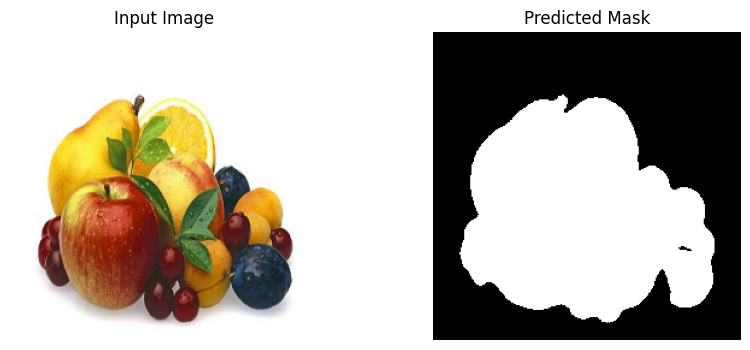

In [15]:
import cv2
import torch
import matplotlib.pyplot as plt

# Directly use the local path
img_path = "/kaggle/input/test-image1/download3.jpg"

# Read the image
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

img_size = 256
image_resized = cv2.resize(image, (img_size, img_size))
image_norm = image_resized.astype("float32") / 255.0

# Tensor
device = "cuda" if torch.cuda.is_available() else "cpu"
input_tensor = torch.tensor(image_norm).permute(2,0,1).unsqueeze(0).to(device)

# Load model
model_path = "/kaggle/working/best_train_unet_full_model.pth"

# Load model (allow pickling of the full object)
model = torch.load(model_path, map_location=device, weights_only=False)
model.eval()

with torch.no_grad():
    pred = model(input_tensor)
    pred_mask = (pred > 0.5).float()

pred_np = pred_mask[0,0].cpu().numpy()

# Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(image_resized)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pred_np, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")
plt.show()
